In [1]:
import psycopg2
from sqlalchemy import create_engine, Column, Integer, String
from sqlalchemy.ext.declarative import declarative_base
from sqlalchemy.orm import sessionmaker
import pandas as pd
import numpy as np
from parameters import db_params
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt


# Create a connection string
conn_string = f"postgresql+psycopg2://{db_params['user']}:{db_params['password']}@{db_params['host']}:{db_params['port']}/{db_params['database']}"

# Create an SQLAlchemy engine
engine = create_engine(conn_string)

# Use pandas to execute a query and load data into a DataFrame
query = "SELECT * FROM data_lake.safe_driving"
df_safe_driving = pd.read_sql(query, engine)

# Close the connection
engine.dispose()

# Ensure 'event_start' and 'event_end' are in datetime format
df_safe_driving['event_start'] = pd.to_datetime(df_safe_driving['event_start'])
df_safe_driving['event_end'] = pd.to_datetime(df_safe_driving['event_end'])

# Check for duplicate values
dup_count = df_safe_driving.duplicated().sum()
print('There are', dup_count, 'duplicate values')

# Re-check for missing values in different forms
missing_count = df_safe_driving.isnull().sum().sum()
print('There are', missing_count, 'missing values')

# Set the future option to opt-in to the new behavior
pd.set_option('future.no_silent_downcasting', True)

# Replace empty strings with NaN in the 'road_number' column
df_safe_driving['road_number'] = df_safe_driving['road_number'].replace("", np.nan)

# Verify that the replacement has been done
missing_values_count = df_safe_driving.isnull().sum()
print("Total missing values per column:")
print(missing_values_count[missing_values_count > 0])

# Summarize findings
total_missing = missing_values_count.sum()
print(f"Total number of missing values (including special values): {total_missing}")

# Verify that the rows with missing values
print(df_safe_driving.isna().sum())

# Print start cleaning
print('\nStarting Cleaning:\n')

# Remove the 'road_number' column
df_safe_driving = df_safe_driving.drop('road_number', axis=1)

# Verify that the rows with missing 'road_number' values have been removed
print(df_safe_driving.isna().sum())

# Strip whitespace from the 'category' column
df_safe_driving['category'] = df_safe_driving['category'].str.strip()

# Print the unique values
print(df_safe_driving['category'].unique())

# Check for duplicate values
dup_count = df_safe_driving.duplicated().sum()
print('After cleaning there are', dup_count, 'duplicate values')

# Re-check for missing values in different forms
missing_count = df_safe_driving.isnull().sum().sum()
print('After cleaning there are', missing_count, 'missing values')

df_safe_driving.head()


There are 0 duplicate values
There are 0 missing values
Total missing values per column:
road_number    964488
dtype: int64
Total number of missing values (including special values): 964488
eventid                   0
event_start               0
event_end                 0
duration_seconds          0
latitude                  0
longitude                 0
speed_kmh                 0
end_speed_kmh             0
maxwaarde                 0
category                  0
incident_severity         0
is_valid                  0
road_segment_id           0
road_manager_type         0
road_number          964488
road_name                 0
place_name                0
municipality_name         0
road_manager_name         0
dtype: int64

Starting Cleaning:

eventid              0
event_start          0
event_end            0
duration_seconds     0
latitude             0
longitude            0
speed_kmh            0
end_speed_kmh        0
maxwaarde            0
category             0
incident_sever

,eventid,event_start,event_end,duration_seconds,latitude,longitude,speed_kmh,end_speed_kmh,maxwaarde,category,incident_severity,is_valid,road_segment_id,road_manager_type,road_name,place_name,municipality_name,road_manager_name
0,96862847,2022-07-08 09:44:25.000,2022-07-08 09:44:31.000,6.0,51.59583,4.705557,41.616074,41.400070,45.684080,SPEED,SP1,True,215201078,G,Moleneind,Prinsenbeek,Breda,Breda
1,96569807,2022-07-08 20:49:51.600,2022-07-08 20:49:53.800,2.2,51.59275,4.829940,40.082466,37.778465,0.965606,HARSH CORNERING,HC1,True,232201050,G,Tilburgseweg,Breda,Breda,Breda
2,96441807,2022-07-08 08:17:34.000,2022-07-08 08:17:41.000,7.0,51.61903,4.771123,64.373760,64.373760,64.373760,SPEED,SP1,True,600919775,G,Terheijdenseweg,Breda,Breda,Breda
3,96444435,2022-07-08 08:23:18.000,2022-07-08 08:23:26.000,8.0,51.59155,4.757880,71.110920,71.643715,75.474130,SPEED,SP2,True,600915496,G,Lunetstraat,Breda,Breda,Breda
4,96442537,2022-07-08 08:11:47.000,2022-07-08 08:12:00.000,13.0,51.59968,4.817744,83.685890,82.076546,85.295235,SPEED,SP1,True,600123602,G,Nieuwe Kadijk,Teteringen,Breda,Breda


In [2]:
# Count the number of rows before removing outliers
rows_before = df_safe_driving.shape[0]

# Define the coordinates of the outliers
outlier_coords = [(51.605330, 4.779188), (51.590760, 4.811617)]

# Remove rows for outliers
for coord in outlier_coords:
    df_safe_driving = df_safe_driving[~((df_safe_driving['latitude'] == coord[0]) & (df_safe_driving['longitude'] == coord[1]))]

# Find the index of the outlier
outlier_index = df_safe_driving[df_safe_driving['duration_seconds'] > 500].index

# Drop the outlier row from the DataFrame
df_safe_driving = df_safe_driving.drop(outlier_index)

# Count the number of rows after removing outliers
rows_after = df_safe_driving.shape[0]

# Calculate the number of rows removed
rows_removed = rows_before - rows_after

# Print the number of rows removed
print("Number of rows removed:", rows_removed)

Number of rows removed: 11


In [3]:
# Initialize LabelEncoder
label_encoder = LabelEncoder()

# Encode the 'category' column
df_safe_driving['category_encoded'] = label_encoder.fit_transform(df_safe_driving['category'])

# Strip whitespace from the 'category' column
df_safe_driving['incident_severity'] = df_safe_driving['incident_severity'].str.strip()

# Print the unique values
print(df_safe_driving['incident_severity'].unique())

def classify_incident_severity_corrected(severity):
    low = ['HA1', 'HB1', 'HC1', 'SP1', 'HC4', 'HC13']
    medium = ['HA2', 'HB2', 'HC2', 'HC5', 'HC7', 'HC14', 'HC16', 'SP2', 'SP3', 'HC6', 'HC8', 'HC10', 'HC15', 'HC17', 'HC19']
    high = ['HA3', 'HB3', 'HC3', 'HC9', 'HC11', 'HC12', 'HC18', 'HC20', 'HC21', 'SP4', 'SP5']
    
    if severity in low:
        return 'Low'
    elif severity in medium:
        return 'Medium'
    elif severity in high:
        return 'High'
    else:
        return 'Unknown'

# Apply the corrected classification function
df_safe_driving['incident_severity_bin'] = df_safe_driving['incident_severity'].apply(classify_incident_severity_corrected)

# Display the updated DataFrame
df_safe_driving.head()

['SP1' 'HC1' 'SP2' 'HC2' 'HC16' 'HC7' 'HA2' 'HC13' 'HB1' 'SP3' 'SP4' 'HA1'
 'HB2' 'HC3' 'HB3' 'HC4' 'HA3' 'HC5' 'HC6' 'HC14' 'HC8' 'HC10' 'HC15'
 'HC17' 'SP5' 'HC19' 'HC11' 'HC20' 'HC18' 'HC21']


,eventid,event_start,event_end,duration_seconds,latitude,longitude,speed_kmh,end_speed_kmh,maxwaarde,category,incident_severity,is_valid,road_segment_id,road_manager_type,road_name,place_name,municipality_name,road_manager_name,category_encoded,incident_severity_bin
0,96862847,2022-07-08 09:44:25.000,2022-07-08 09:44:31.000,6.0,51.59583,4.705557,41.616074,41.400070,45.684080,SPEED,SP1,True,215201078,G,Moleneind,Prinsenbeek,Breda,Breda,3,Low
1,96569807,2022-07-08 20:49:51.600,2022-07-08 20:49:53.800,2.2,51.59275,4.829940,40.082466,37.778465,0.965606,HARSH CORNERING,HC1,True,232201050,G,Tilburgseweg,Breda,Breda,Breda,2,Low
2,96441807,2022-07-08 08:17:34.000,2022-07-08 08:17:41.000,7.0,51.61903,4.771123,64.373760,64.373760,64.373760,SPEED,SP1,True,600919775,G,Terheijdenseweg,Breda,Breda,Breda,3,Low
3,96444435,2022-07-08 08:23:18.000,2022-07-08 08:23:26.000,8.0,51.59155,4.757880,71.110920,71.643715,75.474130,SPEED,SP2,True,600915496,G,Lunetstraat,Breda,Breda,Breda,3,Medium
4,96442537,2022-07-08 08:11:47.000,2022-07-08 08:12:00.000,13.0,51.59968,4.817744,83.685890,82.076546,85.295235,SPEED,SP1,True,600123602,G,Nieuwe Kadijk,Teteringen,Breda,Breda,3,Low


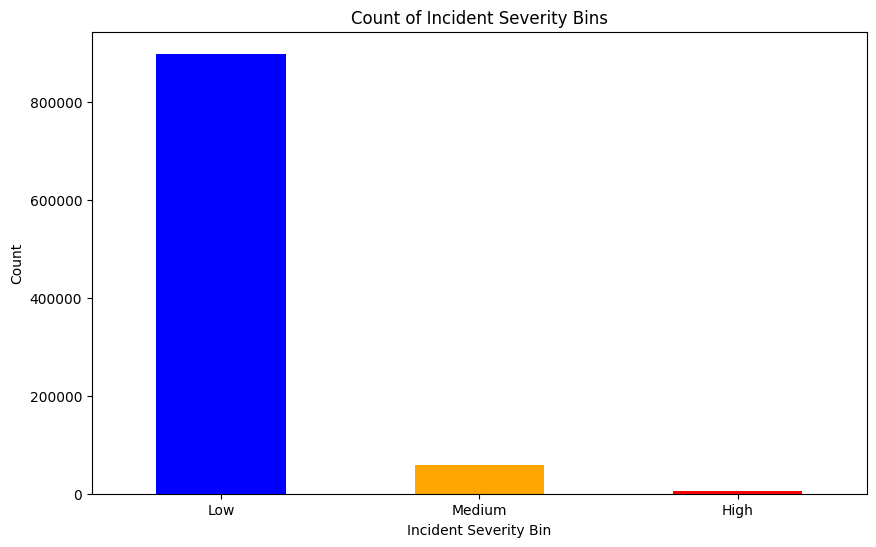

In [4]:
# Create a count histogram for the incident_severity_bin
plt.figure(figsize=(10, 6))
df_safe_driving['incident_severity_bin'].value_counts().plot(kind='bar', color=['blue', 'orange', 'red'])
plt.title('Count of Incident Severity Bins')
plt.xlabel('Incident Severity Bin')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()

Random Sampling with Replacement bin counts:
 incident_severity_bin
High      63533
Low       63533
Medium    63533
Name: count, dtype: int64


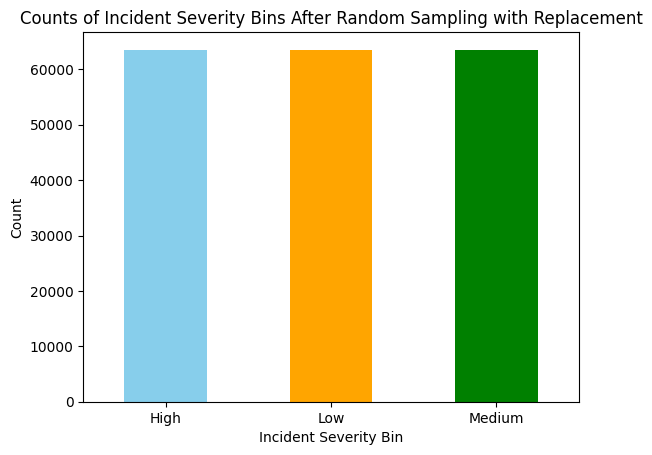

In [5]:
# Apply Random Sampling with Replacement
sampled_dfs = []
for bin_label, group in df_safe_driving.groupby('incident_severity_bin'):
    sampled_dfs.append(group.sample(n=63533, replace=True, random_state=42))
df_sampled_replacement = pd.concat(sampled_dfs)

# Display the count for each incident severity bin in the resampled data
sampled_replacement_bin_counts = df_sampled_replacement['incident_severity_bin'].value_counts()
print("Random Sampling with Replacement bin counts:\n", sampled_replacement_bin_counts)

# Set the resampled DataFrame to df_safe_driving
df_safe_driving = df_sampled_replacement

# Plot histogram
sampled_replacement_bin_counts.plot(kind='bar', color=['skyblue', 'orange', 'green'])
plt.xlabel('Incident Severity Bin')
plt.ylabel('Count')
plt.title('Counts of Incident Severity Bins After Random Sampling with Replacement')
plt.xticks(rotation=0)
plt.show()

In [6]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import tensorflow as tf
import seaborn as sns
import logging
import os
import numpy as np


# Set the information type to 2, this will only show error messages
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

# Suppress TensorFlow warnings
logging.getLogger('tensorflow').setLevel(logging.ERROR)

# Features and target
X = df_safe_driving[['duration_seconds', 'speed_kmh', 'end_speed_kmh', 'maxwaarde', 'category_encoded']]  # Features
y = df_safe_driving['incident_severity_bin']

# Encode the string labels to integers
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

# One-hot encode the target variable
y_one_hot = tf.keras.utils.to_categorical(y_encoded)

# Step 2: Split the data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y_one_hot, test_size=0.2, random_state=42)

# Step 3: Split the train data into train and validation sets
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=42)

# Step 4: Standardize the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

2024-06-06 08:43:44.295406: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-06-06 08:43:44.295468: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2024-06-06 08:43:44.296850: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2024-06-06 08:43:44.304526: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2024-06-06 08:43:45.163571: W tensorflow/compiler/tf2

Iteration 10/100, Training Accuracy: 0.8129, Validation Accuracy: 0.8141
Iteration 20/100, Training Accuracy: 0.8790, Validation Accuracy: 0.8802
Early stopping triggered.


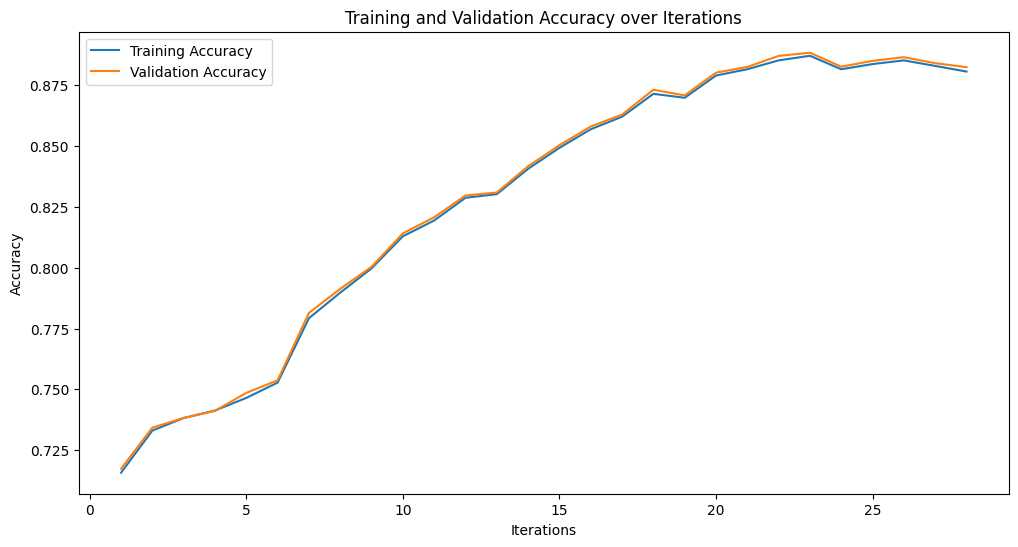

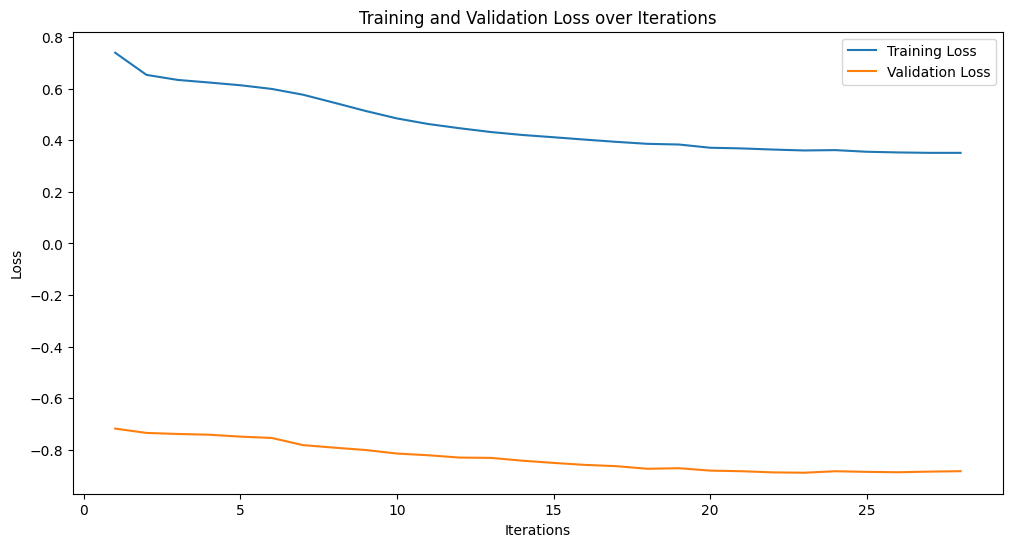

Test Accuracy: 0.88
Classification Report:
               precision    recall  f1-score   support

        High       0.81      0.98      0.88     12607
         Low       0.98      0.90      0.94     12685
      Medium       0.87      0.77      0.82     12828

    accuracy                           0.88     38120
   macro avg       0.89      0.88      0.88     38120
weighted avg       0.89      0.88      0.88     38120



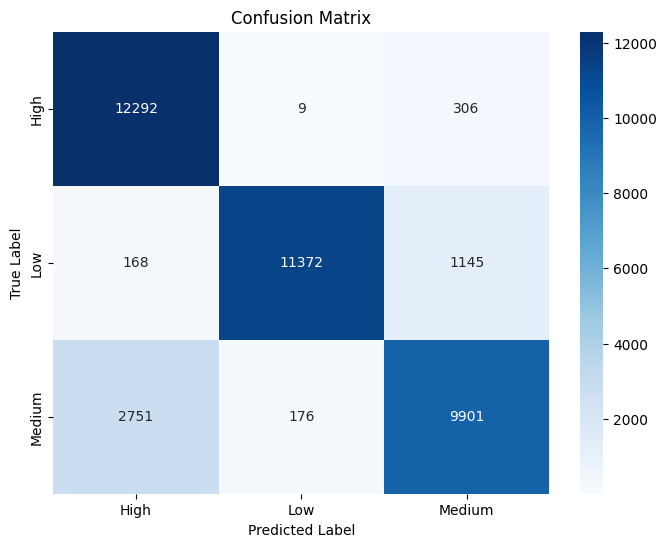

True label: Medium, Predicted label: High
True label: Medium, Predicted label: High
True label: Medium, Predicted label: High
True label: Medium, Predicted label: High
True label: Low, Predicted label: Medium


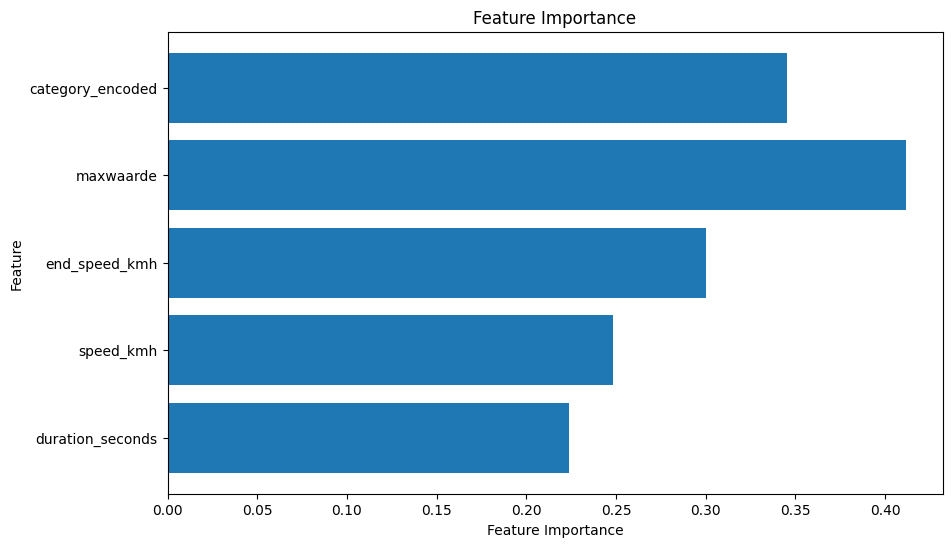

In [11]:
# Create a larger MLPClassifier model 
mlp = MLPClassifier(hidden_layer_sizes=(128, 64, 32), 
                    activation='relu', 
                    solver='adam', 
                    max_iter=1, 
                    random_state=42, 
                    verbose=False)

# Variables to store training and validation accuracies
train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

# Number of iterations to train
num_iterations = 100


# Early stopping callback
class EarlyStoppingCallback:
    def __init__(self, patience=5):
        self.patience = patience
        self.best_val_loss = float('inf')
        self.counter = 0

    def __call__(self, val_loss):
        if val_loss < self.best_val_loss:
            self.best_val_loss = val_loss
            self.counter = 0
        else:
            self.counter += 1

        if self.counter >= self.patience:
            print("Early stopping triggered.")
            return True
        else:
            return False

# Train the model for a number of iterations using partial_fit
early_stopping_callback = EarlyStoppingCallback(patience=5)
for i in range(num_iterations):
    if i == 0:
        mlp.partial_fit(X_train_scaled, y_train.argmax(axis=1), classes=np.unique(y_train.argmax(axis=1)))
    else:
        mlp.partial_fit(X_train_scaled, y_train.argmax(axis=1))

    # Record training accuracy and loss
    train_acc = mlp.score(X_train_scaled, y_train.argmax(axis=1))
    train_loss = mlp.loss_
    train_accuracies.append(train_acc)
    train_losses.append(train_loss)

    # Record validation accuracy and loss
    val_acc = mlp.score(X_val_scaled, y_val.argmax(axis=1))
    val_loss = -mlp.score(X_val_scaled, y_val.argmax(axis=1))  # Approximate validation loss
    val_accuracies.append(val_acc)
    val_losses.append(val_loss)

    # Print progress
    if (i + 1) % 10 == 0:
        print(f"Iteration {i + 1}/{num_iterations}, Training Accuracy: {train_acc:.4f}, Validation Accuracy: {val_acc:.4f}")

    # Check for early stopping
    if early_stopping_callback(val_loss):
        break

# Plot training and validation accuracy
plt.figure(figsize=(12, 6))
min_length = min(len(train_accuracies), len(val_accuracies))
plt.plot(range(1, min_length + 1), train_accuracies[:min_length], label='Training Accuracy')
plt.plot(range(1, min_length + 1), val_accuracies[:min_length], label='Validation Accuracy')
plt.xlabel('Iterations')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy over Iterations')
plt.legend()
plt.show()

# Plot training and validation loss
plt.figure(figsize=(12, 6))
min_length = min(len(train_losses), len(val_losses))
plt.plot(range(1, min_length + 1), train_losses[:min_length], label='Training Loss')
plt.plot(range(1, min_length + 1), val_losses[:min_length], label='Validation Loss')
plt.xlabel('Iterations')
plt.ylabel('Loss')
plt.title('Training and Validation Loss over Iterations')
plt.legend()
plt.show()

# Evaluate the model on the test set
test_score = mlp.score(X_test_scaled, y_test.argmax(axis=1))
print(f"Test Accuracy: {test_score:.2f}")

# Generate predictions
y_pred = mlp.predict(X_test_scaled)

# Classification report
report = classification_report(y_test.argmax(axis=1), y_pred, target_names=label_encoder.classes_)
print("Classification Report:\n", report)

# Confusion matrix
cm = confusion_matrix(y_test.argmax(axis=1), y_pred)

# Plot confusion matrix
def plot_confusion_matrix(cm, class_names):
    """
    Plot the confusion matrix using Seaborn.

    Parameters:
        cm (numpy.ndarray): Confusion matrix.
        class_names (list): List of class names.
    """
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.title('Confusion Matrix')
    plt.show()

plot_confusion_matrix(cm, label_encoder.classes_)

# Perform error analysis
def perform_error_analysis(model, X_test, y_test, class_names):
    """
    Perform error analysis on the model's predictions.

    Parameters:
        model (MLPClassifier): The trained scikit-learn model.
        X_test (numpy.ndarray): The test features.
        y_test (numpy.ndarray): The true labels for the test data.
        class_names (list): List of class names.
    """
    # Generate predictions
    y_pred = model.predict(X_test)
    y_pred_classes = y_pred
    y_test_classes = y_test.argmax(axis=1)

    # Find instances where predictions are incorrect
    incorrect_indices = [i for i, (pred, true) in enumerate(zip(y_pred_classes, y_test_classes)) if pred != true]

    # Display some examples of incorrect predictions
    for idx in incorrect_indices[:5]:
        print(f"True label: {class_names[y_test_classes[idx]]}, Predicted label: {class_names[y_pred_classes[idx]]}")
        

perform_error_analysis(mlp, X_test_scaled, y_test, label_encoder.classes_)

from sklearn.inspection import permutation_importance

def calculate_feature_importance(model, X, y):
    """
    Calculate feature importance using permutation importance.

    Parameters:
        model (sklearn.neural_network.MLPClassifier): The trained scikit-learn model.
        X (numpy.ndarray): The input features.
        y (numpy.ndarray): The target labels.

    Returns:
        feature_importance (numpy.ndarray): Feature importance scores.
    """
    result = permutation_importance(model, X, y.argmax(axis=1), n_repeats=10, random_state=42, n_jobs=-1)
    return result.importances_mean

feature_names = X.columns

# Calculate feature importance
feature_importance = calculate_feature_importance(mlp, X_test_scaled, y_test)

# Plot feature importance
plt.figure(figsize=(10, 6))
plt.barh(range(len(feature_importance)), feature_importance, align='center')
plt.yticks(range(len(feature_importance)), feature_names)
plt.xlabel('Feature Importance')
plt.ylabel('Feature')
plt.title('Feature Importance')
plt.show()